# Flash Attention - V2


In [1]:
from helper import plot
from tile_model import Hardware
from fa import flash_attention
from fa_vanilla import flash_attention_vanilla

## Smooth Quantization & Int8 -> Int16 stability

1. W8A16 outlier

Original LlaMA 8B is a BF16 model, while running on this architecture have to be W8A16. A quantization should be explicitly
designed for rounding.

Ref:  SageAttention2: Efficient Attention with Thorough Outlier Smoothing and Per-thread INT4 Quantization

2. Overflow Int8 -> Int16

For activation, Int 16 and Int8 are used and **radix-16 digit decomposition** has been applied for numerical accumulator stability

$A = A_0 + 16A_1, B = B_0 + 16B_1$

$AB = A_0 B_0 + 16A_0 B_1 + 16 A_1 B_0 + 256 A_1 B_1$

ref: BISMO: A Scalable Bit-Serial Matrix Multiplication Overlay for Reconfigurable Computing



## Prefill

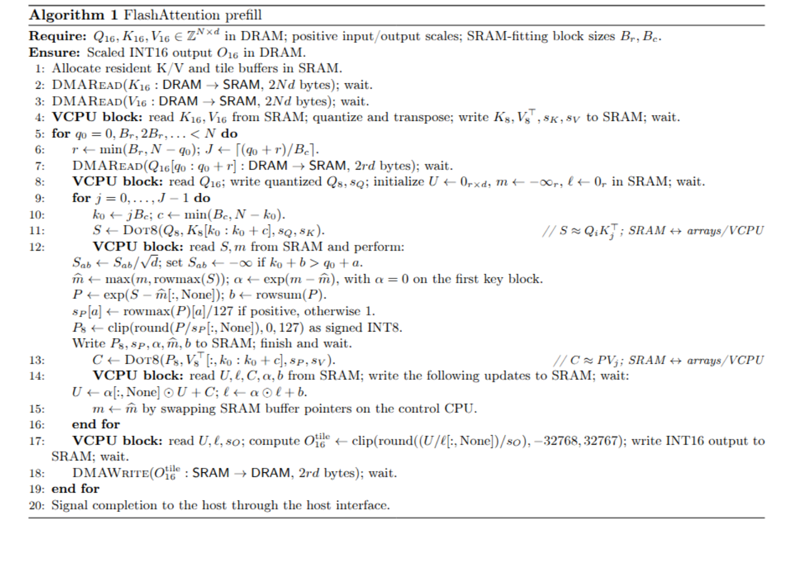

In [2]:
plot("img/fa2_prefill.png", 800)

In [3]:
T=2048
S=2048
H=128
G=4

flash_attention_vanilla(T=T, S=S, H=H, G=G, Br=128, Bc=256, R=128,
                            causal=True, hw=Hardware(), verbose=False)

{'cycles': 13967693,
 'time_ms': 13.967692999999999,
 'busy': {'DMA': 130720, 'VCPU': 3072685, 'SA': 10764288},
 'peak_sram_bytes': 1572872,
 'sram_utilization_percent': 9.37504768371582}

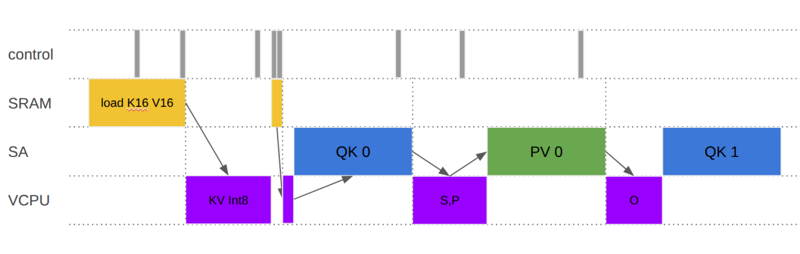

In [4]:
plot("img/fa2_schedule.png", 800)

## Improve:

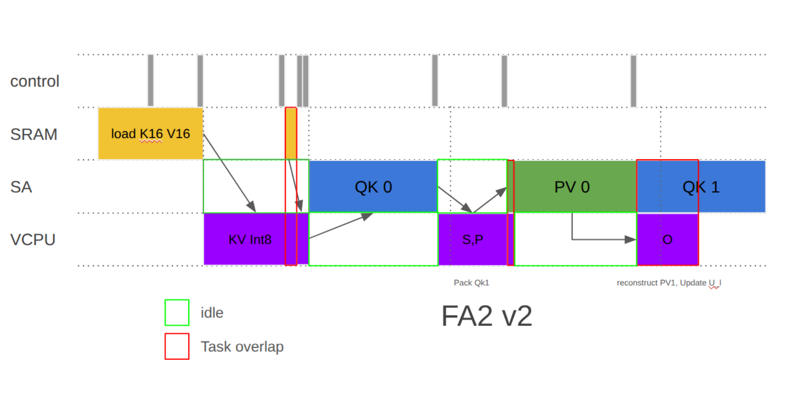

In [5]:
plot("img/schedule_bubble.png", 800)

### Solution: Finer Granularity

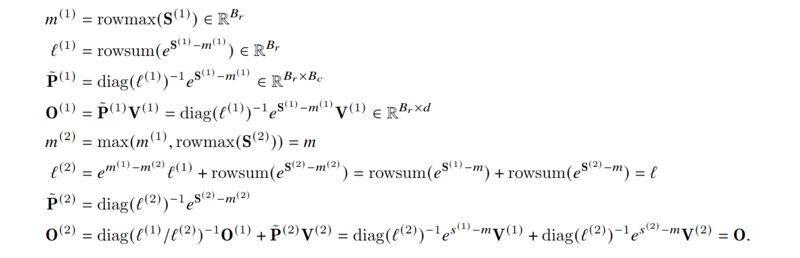

In [6]:
plot("img/online_softmax.png", 800)

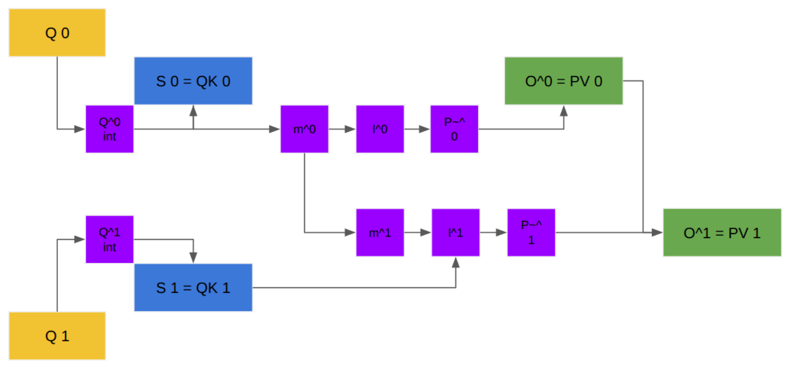

In [7]:
plot("img/schedule_dependency.png", 800)

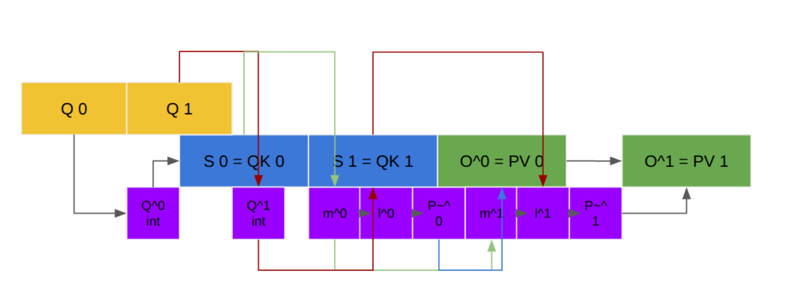

In [8]:
plot("img/schedule_pipeline.png", 800)

    DMA load K16, V16: DRAM → SRAM
    VCPU quantize K16, V16 → K8, V8T; write scales to SRAM
    SRAM release K16, V16 after conversion

    FOR each grouped Q head
        FOR each query tile Qi
            DMA load Qi16: DRAM → SRAM
            VCPU quantize Qi16 → Qi8
            VCPU initialize U = 0, l = 0, m = -infinity
            SRAM release Qi16

            VCPU pack QK operands for blocks 0, 1, 2, if present
            SA1 & SA2 queue QK(0), QK(1), if present

            FOR p = 0 ... last key block
                SA1 & SA2 queue QK(p + 2), if present

                VCPU read QK(p) raw results from SRAM
                VCPU reconstruct and scale scores S
                VCPU apply causal mask

                VCPU compute:
                    m_new = maximum(m, rowmax(S))
                    alpha[p] = exp(m - m_new)
                    P = exp(S - m_new)
                    l = alpha[p] * l + rowsum(P)
                    m = m_new

                VCPU write updated m, l and alpha[p] to SRAM
                VCPU quantize P → P8
                VCPU pack P8, V8T for PV(p)

                VCPU pack QK(p + 3) operands, if present
                SA1 & SA2 queue PV(p); write raw results to SRAM

                IF p >= 1
                    VCPU reconstruct and scale PV(p - 1) → C
                    VCPU read U, C, alpha[p - 1]
                    VCPU write U = alpha[p - 1] * U + C
                    SRAM release consumed block buffers
                END IF
            END FOR

            VCPU reconstruct and scale the final PV → C
            VCPU write U = alpha[last] * U + C

            VCPU normalize O = U / l
            VCPU encode O16 and write to SRAM
            DMA store O16: SRAM → DRAM
            CPU wait for store completion
            SRAM release query-tile buffers
        END FOR
    END FOR

    SRAM release K8, V8T and scales

In [9]:
result = flash_attention(T=T, S=S, H=H, G=G, Br=192, Bc=256, R=128,verbose=False)
result["cycles"], result["time_ms"]

(5434829, 5.434829000000001)

## Control Bound

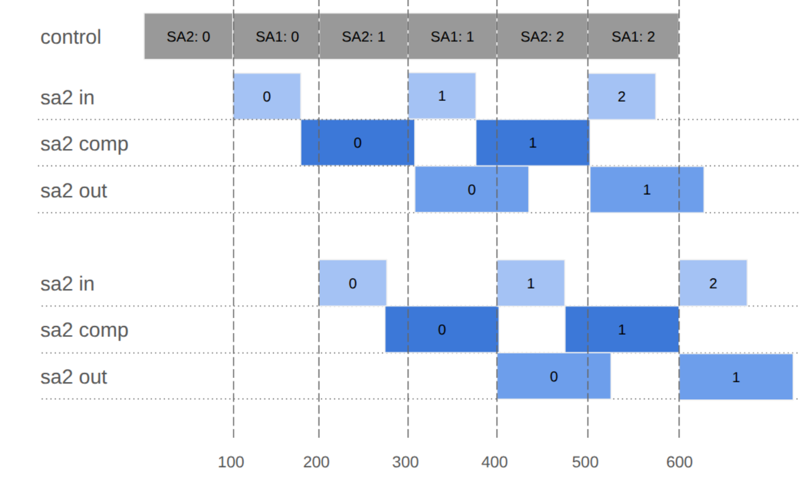

In [10]:
plot("img/control_seq.png", 800)

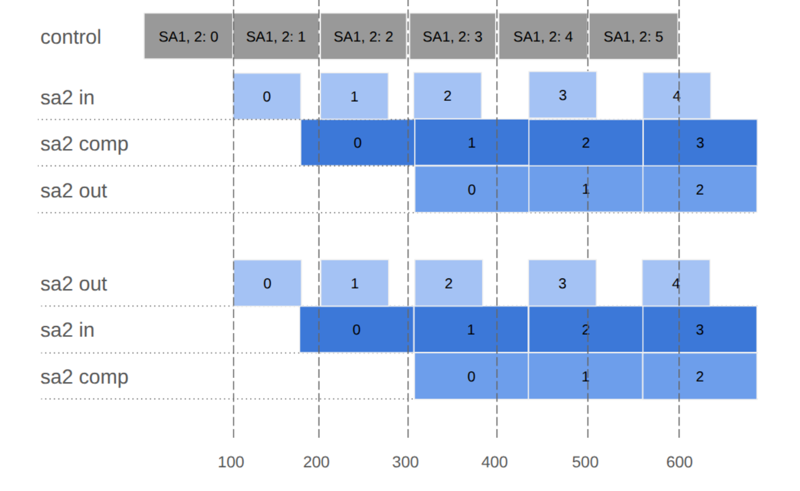

In [11]:
plot("img/control_pipeline.png", 800)

In [12]:
hw_pip = Hardware(control="pipelined")
result_pipelined = flash_attention(T=T, S=S, H=H, G=G, Br=192, Bc=256, R=128,verbose=False, hw=hw_pip)

hw_seq = Hardware(control="serialized")
result_sequential = flash_attention(T=T, S=S, H=H, G=G, Br=192, Bc=256, R=128,verbose=False, hw=hw_seq)

print(f"pipelined cycles: {result_pipelined["cycles"]}", f"sequential cycles: {result_sequential["cycles"]}")
print(f"pipelined ms: {result_pipelined["time_ms"]}", f"sequential ms: {result_sequential["time_ms"]}")

pipelined cycles: 3119402 sequential cycles: 5434829
pipelined ms: 3.119402 sequential ms: 5.434829000000001


## Find the best Br Bc to minimize the overhead

two operations uses SA unit

$$S = Q K^T$$
$$P V$$

$$\min T(B_r, Bc)_{B_r, B_c} s.t. M_{SRAM}(B_r, B_c) <= 16MB$$

### Review of theoretical performance on SA1/SA2

#### Bandwidth model

**The 8 B/c output port is the bottleneck.**

**sa2 has no advantage on K = 128, and a 2x advantage on k = 256.**

**K >= 128 Memory bound, <= computation bound**

when K = 128, sa1 complete same macs in the same cycle (128)

    K=32
    sa1 macs: 8192, cycle:64
    sa2 macs: 16384, cycle:128
    K=64
    sa1 macs: 16384, cycle:64
    sa2 macs: 32768, cycle:128
    K=128
    sa1 macs: 32768, cycle:64
    sa2 macs: 65536, cycle:128
    K=256
    sa1 macs: 65536, cycle:128
    sa2 macs: 131072, cycle:128


suggest: QK: K = 128, both row_size = 32n

-> Br1 = Br2 = Br / 2

-> Br can be divisible by 32 and ideally // 2048

-> Br in {64, 128, 192, 256 512...}

suggest PV: reduction in Bc, should be overflow safe avoids a short final reduction chunk in PV

-> Bc in {128, 256, 512 ...}

suggest: PV: K =256, row_size


#### MAC model

    K=32
    sa1 macs: 8192, cycle:64
    sa2 macs: 16384, cycle:128
    K=64
    sa1 macs: 16384, cycle:64
    sa2 macs: 32768, cycle:128
    K=128
    sa1 macs: 32768, cycle:128
    sa2 macs: 65536, cycle:128
    K=256
    sa1 macs: 65536, cycle:256
    sa2 macs: 131072, cycle:256

suggest: QK: K = 128, 1:1


## Performance analysis

In [13]:
B = 16 # Batch size
L = 32 # Layers
T = 2048 # Q length
S = 2048 # K length
D = 4096 # dimension
F = 14336 # FFN inter dim
N = 32 # Q head
K = 8 # KV head
H = 128 # d_head
G = int(N / K) # Q heads / KV head
d_kv = 1024 # d_kv


In [14]:
from math import ceil
from tile_model import Hardware, DMA, VCPU, SA1, SA2

def analytical(Br_SA1, Br_SA2, Bc, R,
               hw=Hardware(control="pipelined")):

    Br = Br_SA1 + Br_SA2
    G = N // K
    Q_offset = 0

    Digit_pairs = hw.digits**2

    # Your formulas assume pipelined command issue.
    # This helper receives TOTAL vector read + write traffic.
    def vector_cycles(total_bytes):
        return VCPU(
            in_bytes=total_bytes,
            out_bytes=0,
            hw=hw,
        ).launch_cycle()

    # Physical array dimensions and bandwidths come from the classes.
    sa1 = SA1(K=R, compute_model="mac")
    sa2 = SA2(K=R, compute_model="mac")

    # K/V loaded once for all G grouped Q heads.
    DMA_K = DMA(
        nbytes=2 * S * H, direction="read", hw=hw
    ).cycle()

    DMA_V = DMA(
        nbytes=2 * S * H, direction="read", hw=hw
    ).cycle()

    VCPU_KV = vector_cycles(10 * S * H + 16)
    KV_setup = DMA_K + DMA_V + VCPU_KV

    Q_head_BW = 0
    Q_head_MAC = 0

    for q0 in range(0, T, Br):
        r = min(Br, T - q0)
        r1 = min(r, Br_SA1)
        r2 = r - r1

        Row_tiles1 = ceil(r1 / sa1.physical_rows)
        Row_tiles2 = ceil(r2 / sa2.physical_rows)

        Padded_rows = (
            Row_tiles1 * sa1.physical_rows
            + Row_tiles2 * sa2.physical_rows
        )

        DMA_Q = DMA(
            nbytes=2 * r * H, direction="read", hw=hw
        ).cycle()

        DMA_O = DMA(
            nbytes=2 * r * H, direction="write", hw=hw
        ).cycle()

        VCPU_Q = vector_cycles(9 * r * H + 8 * r + 8)
        VCPU_O = vector_cycles(6 * r * H + 4 * r + 4)

        Q_head_BW += DMA_Q + DMA_O + VCPU_Q + VCPU_O
        Q_head_MAC += DMA_Q + DMA_O + VCPU_Q + VCPU_O

        for k0 in range(0, min(S, Q_offset + q0 + r), Bc):
            c = min(Bc, S - k0)

            Softmax = vector_cycles(17 * r * c + 28 * r)
            Update = vector_cycles(12 * r * H + 16 * r)

            Q_head_BW += Softmax + Update
            Q_head_MAC += Softmax + Update

            for product, columns, reduction in [
                ("QK", c, H),
                ("PV", H, c),
            ]:
                Chunks = ceil(reduction / R)

                # Preserve your fixed-depth padding.
                Padded_reduction = Chunks * R

                # Both arrays have 16 physical output columns.
                Physical_columns = sa1.output_bytes() // (
                    sa1.physical_rows * 2
                )
                Column_tiles = ceil(columns / Physical_columns)
                Padded_columns = Column_tiles * Physical_columns

                Jobs1 = Row_tiles1 * Column_tiles * Chunks * Digit_pairs
                Jobs2 = Row_tiles2 * Column_tiles * Chunks * Digit_pairs

                Raw_bytes = (
                    Jobs1 * sa1.output_bytes()
                    + Jobs2 * sa2.output_bytes()
                )

                Pack = vector_cycles(
                    (r + columns) * reduction
                    + hw.digits
                    * (Padded_rows + Padded_columns)
                    * Padded_reduction
                )

                Scale_bytes = 8 if product == "QK" else 4 * r + 4

                Recon = vector_cycles(
                    Raw_bytes
                    + 4 * r * columns
                    + Scale_bytes
                )

                # Preserve your first-command ordering.
                Start1 = 0 if Jobs1 > Jobs2 else hw.issue_interval
                Start2 = hw.issue_interval if Jobs1 > Jobs2 else 0

                End_BW = []
                End_MAC = []

                for sa, jobs, start in [
                    (sa1, Jobs1, Start1),
                    (sa2, Jobs2, Start2),
                ]:
                    if jobs == 0:
                        End_BW.append(0)
                        End_MAC.append(0)
                        continue

                    Input = sa.input_cycles()
                    Output = sa.output_cycles()
                    Compute = sa.compute_cycles()  # R in MAC model.

                    End_BW.append(
                        start
                        + hw.array_latency
                        + Input
                        + Output
                        + (jobs - 1) * max(Input, Output)
                    )

                    End_MAC.append(
                        start
                        + hw.array_latency
                        + Input
                        + Compute
                        + Output
                        + (jobs - 1) * max(Input, Compute, Output)
                    )

                Q_head_BW += Pack + Recon + max(End_BW)
                Q_head_MAC += Pack + Recon + max(End_MAC)

    First_Q_DMA = DMA(
        nbytes=2 * min(Br, T) * H,
        direction="read",
        hw=hw,
    ).cycle()

    Hidden_Q_DMA = min(
        First_Q_DMA,
        VCPU_KV - hw.vector_launch,
    )

    FA2_BW_cycles = KV_setup + G * Q_head_BW - Hidden_Q_DMA
    FA2_MAC_cycles = KV_setup + G * Q_head_MAC - Hidden_Q_DMA

    FA2_BW_ms = round(hw.time_us(FA2_BW_cycles) / 1000, 3)
    FA2_MAC_ms = round(hw.time_us(FA2_MAC_cycles) / 1000, 3)

    return FA2_BW_ms, FA2_MAC_ms

Grid search

In [15]:
for R in [64, 128, 256]:
    for Br_SA1 in [16, 32, 64, 128, 256]: # Must be a multiple of 16
        for Br_SA2 in [32, 64, 128, 256]:
            for Bc in  [128, 256, 512]:
                FA2_BW_ms, FA2_MAC_ms = analytical(Br_SA1, Br_SA2, Bc, R)
                print(R, Br_SA1, Br_SA2, Bc, FA2_BW_ms, FA2_MAC_ms)
    print("*"*72)

64 16 32 128 13.912 14.103
64 16 32 256 12.358 12.459
64 16 32 512 12.349 12.405
64 16 64 128 13.546 13.664
64 16 64 256 12.56 12.622
64 16 64 512 12.969 13.003
64 16 128 128 13.882 13.954
64 16 128 256 13.282 13.32
64 16 128 512 13.699 13.72
64 16 256 128 14.229 14.27
64 16 256 256 14.455 14.477
64 16 256 512 14.929 14.94
64 32 32 128 11.101 11.24
64 32 32 256 9.862 9.936
64 32 32 512 9.875 9.916
64 32 64 128 12.103 12.204
64 32 64 256 11.23 11.283
64 32 64 512 11.463 11.492
64 32 128 128 12.612 12.672
64 32 128 256 12.034 12.066
64 32 128 512 12.532 12.549
64 32 256 128 13.883 13.925
64 32 256 256 13.561 13.583
64 32 256 512 14.06 14.072
64 64 32 128 12.103 12.204
64 64 32 256 11.23 11.283
64 64 32 512 11.463 11.492
64 64 64 128 9.611 9.68
64 64 64 256 8.885 8.922
64 64 64 512 9.13 9.151
64 64 128 128 11.05 11.101
64 64 128 256 10.47 10.497
64 64 128 512 10.866 10.881
64 64 256 128 12.405 12.441
64 64 256 256 12.16 12.179
64 64 256 512 12.713 12.723
64 128 32 128 12.874 12.935
64 128

**128 128 128 256 13.897725 23.353053**

**128 64 128 256 17.749221 18.847909**

for bandwidth 1:1, mac 1:2

### Using Hardware model

In [16]:
result = flash_attention(T=T, S=S, H=H, G=G, Br=192, Bc=256, R=128,gantt_path="gantt")

Load K16                                   DMA    @          0     8,592 cycles     8.592 us  SRAM    512.00 KiB
Quantize K                                 VCPU   @      8,592    10,541 cycles    10.541 us  SRAM   1280.00 KiB
Load V16                                   DMA    @      8,592     8,592 cycles     8.592 us  SRAM   1280.00 KiB
h0 q0 load Q16                             DMA    @     17,184     1,168 cycles     1.168 us  SRAM   1328.00 KiB
h0 q0 quantize Q + init U,l,m              VCPU   @     19,133     2,041 cycles     2.041 us  SRAM    937.51 KiB
h0 q0 k0 QK pack                           VCPU   @     21,174     1,260 cycles     1.260 us  SRAM   1009.51 KiB
h0 q192 load Q16                           DMA    @     21,174     1,168 cycles     1.168 us  SRAM   1009.51 KiB
h0 q192 quantize Q + init U,l,m            VCPU   @     22,434     2,041 cycles     2.041 us  SRAM   1171.51 KiB
h0 q0 k0 QK                                ARRAYS @     22,434     7,068 cycles     7.068 us  SR

## Bottleneck analysis

In [17]:

import tile_model
import fa
import sys, dataclasses

def run(label, hw, **kw):
    fa._array_matmul.cache_clear(); fa._balanced_split.cache_clear()
    r = flash_attention(T=2048,S=2048,H=128,G=4,Br=192,Bc=256,Br_sa1=None,R=256,hw=hw,verbose=False,**kw)
    u = r['utilization']
    macs = 4*sum(m*c*128*2 for _ in [0] for m,c in [(192,256)])  # placeholder
    print(f'{label:46s} {r["time_ms"]:7.3f} ms  arrays {100*u["SA1+SA2"]:5.1f}%  vcpu {100*u["VCPU"]:5.1f}%  dma {100*u["DMA"]:4.1f}%')

    return r

base = Hardware()
# per-job anatomy



run('baseline', base)
run('DMA bandwidth x4', dataclasses.replace(base, dma_bw=256))
run('vector bandwidth x2', dataclasses.replace(base, vector_bw=256))
run('vector launch 300 -> 0', dataclasses.replace(base, vector_launch=0))
run('array command latency 100 -> 0', dataclasses.replace(base, array_latency=0))
run('pipelined command issue', dataclasses.replace(base, control='pipelined'))
run('array_model=bandwidth (no MAC limit)', dataclasses.replace(base, array_model='bandwidth'))
run('pipelined + bandwidth model', dataclasses.replace(base, control='pipelined', array_model='bandwidth'))
# output port 8 -> 16 B/cycle (class attribute, patched for the experiment only)
tile_model.SystolicArray.BW_out = 16
run('output port 8 -> 16 B/cycle (mac model)', base)
run('output port x2 + pipelined', dataclasses.replace(base, control='pipelined'))
run('output port x2 + pipelined + bandwidth', dataclasses.replace(base, control='pipelined', array_model='bandwidth'))
tile_model.SystolicArray.BW_out = 8
run('pipelined + vector bw x2', dataclasses.replace(base, control='pipelined', vector_bw=256))
print()

baseline                                         4.873 ms  arrays  99.4%  vcpu  58.4%  dma  2.4%
DMA bandwidth x4                                 4.867 ms  arrays  99.6%  vcpu  58.5%  dma  1.1%
vector bandwidth x2                              4.869 ms  arrays  99.5%  vcpu  33.4%  dma  2.4%
vector launch 300 -> 0                           4.871 ms  arrays  99.5%  vcpu  50.1%  dma  2.4%
array command latency 100 -> 0                   3.078 ms  arrays  98.7%  vcpu  92.5%  dma  3.8%
pipelined command issue                          3.118 ms  arrays  98.8%  vcpu  91.3%  dma  3.7%
array_model=bandwidth (no MAC limit)             3.761 ms  arrays  99.2%  vcpu  75.6%  dma  3.1%
pipelined + bandwidth model                      2.856 ms  arrays  68.2%  vcpu  99.7%  dma  4.1%
output port 8 -> 16 B/cycle (mac model)          4.847 ms  arrays  99.4%  vcpu  58.8%  dma  2.4%
output port x2 + pipelined                       3.094 ms  arrays  98.7%  vcpu  92.1%  dma  3.7%
output port x2 + pipelined + b

### Conclusion

FA2_overlap

SA distribution

Best practice Br

Quantization: Accumulator overflow and quantization control on FA

Problems:

    1 Output bottleneck: The sa computation is largely limited by its output bound (See hardware profile). SA2 optimal K = 256, but restricted by quantization K<= 128, otherwise overflow could happen.

    2 Different Br doesn't improve. the Br1 and Br2 doesn't get any improve compare with identical Br for both sa


3 pipeline instruction

